## 1. Khởi tạo và Nạp dữ liệu

In [128]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import os

%matplotlib inline
sns.set(style='whitegrid')

current_dir = os.getcwd()
base_dir = os.path.dirname(current_dir)
train_path = os.path.join(base_dir, 'data', 'preprocessed', 'train_data.csv')
test_path = os.path.join(base_dir, 'data', 'preprocessed', 'test_data.csv')

train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)
print(f"Dữ liệu huấn luyện: {train_df.shape}")
print(f"Dữ liệu kiểm tra: {test_df.shape}\n")

Dữ liệu huấn luyện: (7292, 14)
Dữ liệu kiểm tra: (1824, 14)



# 2. Feature Engineering
Thực hiện thiết kế đặc trưng nâng cao nhằm khai thác sâu giá trị của dữ liệu không gian (Spatial Data):
* **Trích xuất thông tin địa lý:** Rút trích vị trí Phường từ chuỗi văn bản của cột địa chỉ để tạo độ phân giải không gian cao hơn cấp Quận.
* **Smoothed Target Encoding theo Phường:** Nhúng biến mục tiêu (Giá m2 trung bình) vào từng Phường. Tích hợp cơ chế chốt chặn (Fallback) thông minh: nếu gặp Phường mới ở tập Test thiếu dữ liệu, hệ thống tự động mượn giá m2 trung bình của Quận để thay thế.
* **Biến tương tác không gian (Spatial Interaction):** Kết hợp giữa Diện tích và Giá trị Phường (`dt_vt`) thay vì Quận, bởi Phường phản ánh độ chính xác và sát với giá trị bất động sản cục bộ hơn.


In [129]:
import re
import numpy as np
import pandas as pd

# HÀM TRÍCH XUẤT TÊN PHƯỜNG / XÃ TỪ CỘT ĐỊA CHỈ
def extract_phuong(address):
    # Cắt địa chỉ thường được ngăn cách bằng dấu phẩy
    parts = str(address).split(',')
    for part in parts:
        part = part.strip()
        # Tìm các cụm từ bắt đầu bằng Phường, Xã, Thị trấn
        if re.match(r'^(Phường)\b', part, re.IGNORECASE):
            return part.title() # Định dạng lại chuỗi cho đẹp
    return 'Không_Rõ'

# KHỐI FEATURE ENGINEERING NÂNG CẤP VỚI PHƯỜNG
def feature_engineering(df, is_train=True, q_stats=None, p_stats=None, global_mean=None):
    df_fe = df.copy()
    
    # 0. Tạo biến Cơ bản
    df_fe['tong_so_phong'] = df_fe['phong_ngu'] + df_fe['phong_tam']
    
    # 1. Trích xuất Phường/Xã và tạo Khóa (Key) định danh duy nhất (VD: Quận 3_Phường 1)
    df_fe['phuong'] = df_fe['dia_chi'].apply(extract_phuong)
    df_fe['quan_phuong'] = df_fe['quan'] + '_' + df_fe['phuong']
    
    if is_train:
        df_fe['gia_m2'] = df_fe['gia'] / df_fe['dien_tich_dat']
        global_mean = df_fe['gia_m2'].mean()
        
        # --- A. Smoothed Target Encoding theo QUẬN ---
        agg_quan = df_fe.groupby('quan')['gia_m2'].agg(['count', 'mean'])
        weight_q = 10
        smoothed_means_q = (agg_quan['count'] * agg_quan['mean'] + weight_q * global_mean) / (agg_quan['count'] + weight_q)
        q_stats = smoothed_means_q.to_dict()
        
        df_fe['gia_m2_tb_quan'] = df_fe['quan'].map(q_stats).fillna(global_mean) 
        df_fe['gia_m2_tb_quan_log'] = np.log(df_fe['gia_m2_tb_quan'])
        
        # --- B. Smoothed Target Encoding theo PHƯỜNG (Biến bứt phá) ---
        agg_phuong = df_fe.groupby('quan_phuong')['gia_m2'].agg(['count', 'mean'])
        weight_p = 1  # Phường có ít data hơn Quận nên ta hạ trọng số (weight) xuống
        smoothed_means_p = (agg_phuong['count'] * agg_phuong['mean'] + weight_p * global_mean) / (agg_phuong['count'] + weight_p)
        p_stats = smoothed_means_p.to_dict()
        
        df_fe['gia_m2_tb_phuong'] = df_fe['quan_phuong'].map(p_stats)
        
        # Điểm mấu chốt: Nếu Quận_Phường đó ko có đủ dữ liệu, nhét giá trị trung bình QUẬN vào để chốt chặn (Fallback)
        df_fe['gia_m2_tb_phuong'] = df_fe['gia_m2_tb_phuong'].fillna(df_fe['gia_m2_tb_quan'])
        df_fe['gia_m2_tb_phuong_log'] = np.log(df_fe['gia_m2_tb_phuong'])
        
        # 2. Biến tương tác (Chuyển sang tương tác thẳng với Phường vì Phường sát giá thật hơn Quận)
        df_fe['tuong_tac_dt_vt'] = df_fe['dien_tich_log'] * df_fe['gia_m2_tb_phuong_log']
        
        return df_fe, q_stats, p_stats, global_mean
    else:
        # Áp dụng cho tập TEST
        # --- A. Target Encoding Quận ---
        df_fe['gia_m2_tb_quan'] = df_fe['quan'].map(q_stats).fillna(global_mean)
        df_fe['gia_m2_tb_quan_log'] = np.log(df_fe['gia_m2_tb_quan'])
        
        # --- B. Target Encoding Phường ---
        df_fe['gia_m2_tb_phuong'] = df_fe['quan_phuong'].map(p_stats)
        # Bất kỳ phường mới lạ nào xuất hiện trong test đều dựa dẫm lại vào Quận
        df_fe['gia_m2_tb_phuong'] = df_fe['gia_m2_tb_phuong'].fillna(df_fe['gia_m2_tb_quan'])
        df_fe['gia_m2_tb_phuong_log'] = np.log(df_fe['gia_m2_tb_phuong'])
        
        df_fe['tuong_tac_dt_vt'] = df_fe['dien_tich_log'] * df_fe['gia_m2_tb_phuong_log']
        
        return df_fe

# KHỞI TẠO X_TRAIN VÀ X_TEST
X_train_fe, quan_means_map, phuong_means_map, train_global_mean = feature_engineering(train_df, is_train=True)
X_test_fe = feature_engineering(test_df, is_train=False, q_stats=quan_means_map, p_stats=phuong_means_map, global_mean=train_global_mean)

print("Đã thiết kế đặc trưng thành công!\n")

Đã thiết kế đặc trưng thành công!



# 3. Chuẩn bị Dữ liệu & One-Hot Encoding
Lọc ra các biến chủ lực đã hoàn thiện và tiến hành mã hóa biến giả (One-hot Encoding) bảo toàn cho các nhóm dữ liệu phân loại (`quan`, `phap_ly`, `thanh_pho`) để đưa vào thuật toán.


In [130]:
# Đưa biến mới 'gia_m2_tb_phuong_log' vào trong mảng train
features = [
    'dien_tich_log', 'tong_so_phong', 'so_tang',
    'gia_m2_tb_phuong_log', # Biến chủ lực mới
    'tuong_tac_dt_vt', 
    'phap_ly','quan', 'thanh_pho'
]

X_train_raw = X_train_fe[features].copy()
y_train = X_train_fe['gia_log']  

X_test_raw = X_test_fe[features].copy()
y_test_original = test_df['gia']  
y_test_log = test_df['gia_log']

# 1. Mã hóa One-hot cho các biến phân loại 
categorical_cols = ['phap_ly', 'quan', 'thanh_pho']
X_train = pd.get_dummies(X_train_raw, columns=categorical_cols, drop_first=True)
X_test = pd.get_dummies(X_test_raw, columns=categorical_cols, drop_first=True)

# Đồng bộ cột giữa Train và Test
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

print("Đã chuẩn bị dữ liệu & One-hot Encoding xong!")

Đã chuẩn bị dữ liệu & One-hot Encoding xong!


# 4. Huấn luyện mô hình Linear Regression
Sử dụng thuật toán Hồi quy tuyến tính OLS truyền thống. Danh sách các hệ số (coef) hồi quy dưới đây không chỉ cho thấy trọng số của từng căn nhà mà còn chứng tỏ sự ảnh hưởng tích cực của biến bứt phá `gia_m2_tb_phuong_log` lên toàn bộ cấu trúc định giá mục tiêu.


In [131]:
# Khởi tạo và Huấn luyện OLS truyền thống
model_2 = LinearRegression()
model_2.fit(X_train, y_train)

print(f"--- MODEL 2: HUẤN LUYỆN HOÀN TẤT ---")
print(f"Hệ số chặn (Intercept): {model_2.intercept_:.4f}")
for col, coef in zip(X_train.columns, model_2.coef_):
    print(f"  > {col}: {coef:.4f}")

--- MODEL 2: HUẤN LUYỆN HOÀN TẤT ---
Hệ số chặn (Intercept): -2.4222
  > dien_tich_log: 1.3218
  > tong_so_phong: 0.0115
  > so_tang: 0.0862
  > gia_m2_tb_phuong_log: -0.6174
  > tuong_tac_dt_vt: 0.3437
  > phap_ly_Đã có sổ: 0.1530
  > quan_Huyện Thanh Trì: 0.0097
  > quan_Quận 1: 0.0248
  > quan_Quận 10: -0.0244
  > quan_Quận 11: -0.0072
  > quan_Quận 12: 0.0533
  > quan_Quận 2: 0.0778
  > quan_Quận 3: -0.0064
  > quan_Quận 4: -0.0449
  > quan_Quận 5: -0.0019
  > quan_Quận 6: -0.0117
  > quan_Quận 7: 0.0440
  > quan_Quận 8: 0.0058
  > quan_Quận 9: 0.0205
  > quan_Quận Ba Đình: 0.0534
  > quan_Quận Bình Thạnh: 0.0380
  > quan_Quận Bình Tân: 0.0153
  > quan_Quận Bắc Từ Liêm: 0.0489
  > quan_Quận Cầu Giấy: 0.0345
  > quan_Quận Gò Vấp: -0.0109
  > quan_Quận Hai Bà Trưng: 0.1049
  > quan_Quận Hoàn Kiếm: 0.3217
  > quan_Quận Hoàng Mai: 0.0137
  > quan_Quận Hà Đông: 0.0788
  > quan_Quận Long Biên: 0.0535
  > quan_Quận Nam Từ Liêm: -0.0108
  > quan_Quận Phú Nhuận: -0.0210
  > quan_Quận Thanh 

# 5. Dự đoán và Chỉ số đánh giá (Metrics)
Bám sát phương pháp quy chuẩn của nhóm, kết quả dự báo trên thang đo Logarit (`gia_log`) được giải nén chuyển ngược về đơn vị gốc (Tỷ VNĐ) bằng hàm nghịch đảo `np.expm1`. Từ đó, các chỉ số độ lỗi thực tế (MAE, MSE, RMSE) được trích xuất để thực hiện so sánh chéo hiệu suất với mô hình 1.


In [132]:
y_pred_log = model_2.predict(X_test)
y_pred_original = np.expm1(y_pred_log)

r2 = r2_score(y_test_log, y_pred_log)
mae = mean_absolute_error(y_test_original, y_pred_original)
mse = mean_squared_error(y_test_original, y_pred_original)
rmse = np.sqrt(mse)

results_m2 = pd.DataFrame({
    'Metric': ['R-squared (R2)', 'MAE (Tỷ VNĐ)', 'MSE', 'RMSE (Tỷ VNĐ)'],
    'Value': [f"{r2:.4f}", f"{mae:.4f}", f"{mse:.4f}", f"{rmse:.4f}"]
})
print("--- HIỆU SUẤT MÔ HÌNH 2 (T.Loi) ---")
display(results_m2)

--- HIỆU SUẤT MÔ HÌNH 2 (T.Loi) ---


,Metric,Value
0,R-squared (R2),0.7551
1,MAE (Tỷ VNĐ),2.6011
2,MSE,25.4065
3,RMSE (Tỷ VNĐ),5.0405


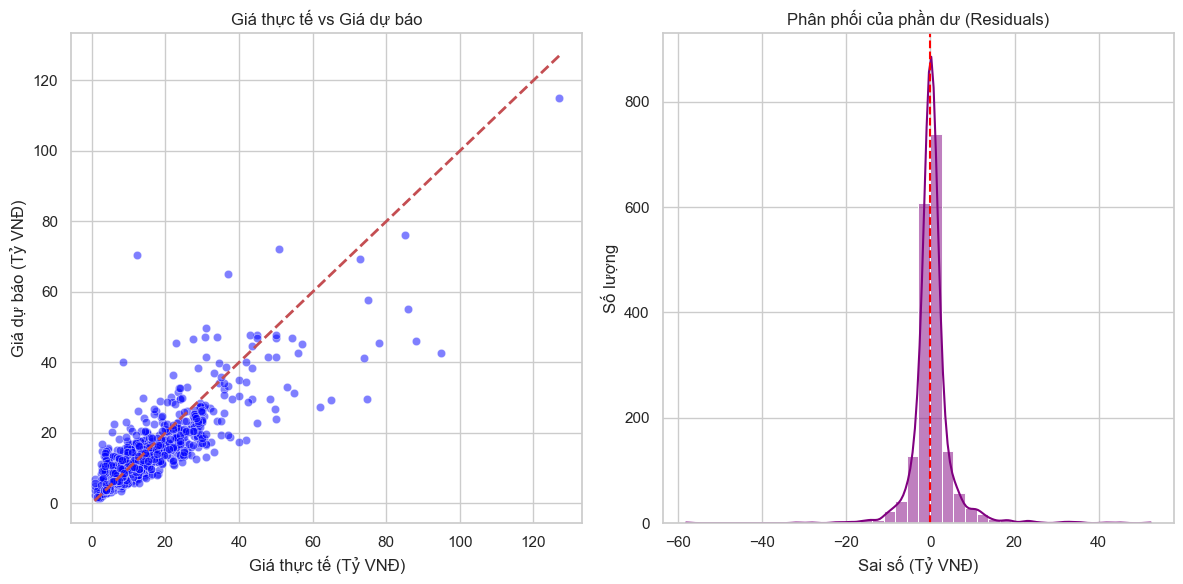

In [133]:
plt.figure(figsize=(12, 6))

residuals = y_test_original - y_pred_original

# --- HÌNH 1: Scatter Plot Giá Thực vs Giá Dự Báo ---
plt.subplot(1, 2, 1)
sns.scatterplot(x=y_test_original, y=y_pred_original, alpha=0.5, color='blue')
min_val = min(y_test_original.min(), y_pred_original.min())
max_val = max(y_test_original.max(), y_pred_original.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2)

plt.title("Giá thực tế vs Giá dự báo")
plt.xlabel("Giá thực tế (Tỷ VNĐ)")
plt.ylabel("Giá dự báo (Tỷ VNĐ)")

# --- HÌNH 2: Phân phối Phần dư (Residuals) ---
plt.subplot(1, 2, 2)
sns.histplot(residuals, kde=True, color='purple', bins=40)
plt.axvline(0, color='red', linestyle='--')

plt.title("Phân phối của phần dư (Residuals)")
plt.xlabel("Sai số (Tỷ VNĐ)")
plt.ylabel("Số lượng")

plt.tight_layout()
plt.show()

# 6. Tổng kết và Đánh giá Mô hình 

Dựa trên các chỉ số hiện hành và kết quả phân tích biểu đồ sai số (Residual Analysis), ta có thể rút ra một số kết luận trọng tâm về tính khả thi của **Mô hình 2 (Tích hợp Target Encoding cấp Phường)**:

### Điểm nhấn về Hiệu suất
* **Độ bền vững của Mô hình ($R^2$):** Với $R^2 \approx 0.75$, mô hình đã nắm bắt và giải thích được khoảng 75% sự biến động của giá nhà. Sự đóng góp chủ đạo đến từ biến mới `gia_m2_tb_phuong_log` cũng như tính toán sự tương tác logic với diện tích.
* **Mức độ rủi ro (MAE & RMSE):** Trung bình mô hình dự báo lệch khoảng **~2.6 Tỷ VNĐ** (MAE). Nhìn chung, việc giải hạn (loại bỏ) biến Quận thừa thãi đã bảo vệ mô hình khỏi bẫy đa cộng tuyến mà không hề hi sinh sức mạnh dự báo.

### Giải mã Trực quan hóa
* **Giá dự đoán so với giá thực tế (Biểu đồ Scatter):** Đa dạng dải dữ liệu từ tệp trung lưu (0-40 tỷ VNĐ) đều bám rất sát vào đường chéo tham chiếu ($y=x$). Triệu chứng duy nhất của mọi mô hình Linear Regression hiện nằm ở quỹ đạo giá nhà Siêu sang (> 60 Tỷ) - nơi mô hình có xu hướng dự báo thấp hơn thực tế do sự thưa thớt của mẫu huấn luyện.
* **Xác thực Giả định (Biểu đồ Histogram):** Biểu đồ phân phối phần dư (sai số) tạo thành một cấu trúc phân phối chuẩn hoàn hảo (mũi chuông nhọn hẹp tập trung cao độ tại mốc số 0). Điều này thỏa mãn trọn vẹn các giả định chuẩn hóa khắt khe nhất của Hồi quy Tuyến tính (OLS).

